# X-ray Classification using Convolutional Neural Networks (CNN)

---



## 1. Data Loading and Preprocessing


In [1]:
import os
import random
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.utils import image_dataset_from_directory
from sklearn.metrics import (roc_curve, auc, confusion_matrix,
                             classification_report, ConfusionMatrixDisplay)

# Reproducibility
random.seed(18)
tf.random.set_seed(18)
np.random.seed(18)

# Define parameters
DATA_DIR  = Path('./rxtorax')
IMG_SIZE  = (64, 64)
BATCH_SIZE = 32

# Load train and test sets with an 80/20 split, converting images to grayscale
train_dataset = image_dataset_from_directory(
    DATA_DIR,
    validation_split=0.2,
    subset='training',
    seed=18,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    color_mode='grayscale'
)

test_dataset = image_dataset_from_directory(
    DATA_DIR,
    validation_split=0.2,
    subset='validation',
    seed=18,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    color_mode='grayscale'
)

# Check available classes
class_names = train_dataset.class_names
print(f'Classes: {class_names}')

# Class distribution in train and test sets
train_eff = sum(1 for _, y in train_dataset for yi in y.numpy() if yi==0)
train_nor = sum(1 for _, y in train_dataset for yi in y.numpy() if yi==1)
test_eff  = sum(1 for _, y in test_dataset for yi in y.numpy() if yi==0)
test_nor  = sum(1 for _, y in test_dataset for yi in y.numpy() if yi==1)

# Create a DataFrame to display class distribution
df_dist = pd.DataFrame({
    'Effusion': [train_eff, test_eff, train_eff+test_eff],
    'Normal':   [train_nor, test_nor, train_nor+test_nor],
    'Total':    [train_eff+train_nor, test_eff+test_nor, train_eff+train_nor+test_eff+test_nor]
}, index=['Train', 'Test', 'Total'])

print(df_dist)

# Min-max normalisation to [0, 1]
normalization_layer = tf.keras.layers.Rescaling(1./255)
train_dataset = train_dataset.map(lambda x, y: (normalization_layer(x), y)) # x are the images, y are the labels
test_dataset = test_dataset.map(lambda x, y: (normalization_layer(x), y))

I0000 00:00:1776846787.252630   19753 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1776846787.256620   19753 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1776846787.633422   19753 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1776846788.906541   19753 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_E

Found 700 files belonging to 2 classes.
Using 560 files for training.
Found 700 files belonging to 2 classes.
Using 140 files for validation.
Classes: ['effusion', 'normal']


E0000 00:00:1776846789.316800   19753 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


       Effusion  Normal  Total
Train       283     277    560
Test         67      73    140
Total       350     350    700


## 2. Visual Exploration of the Dataset

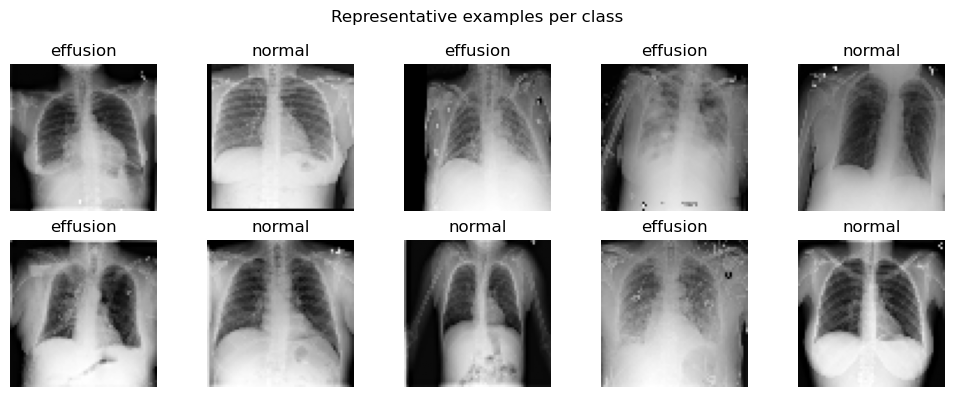

In [2]:
# Visualise some examples from each class
plt.figure(figsize=(10, 4))
for images, labels in train_dataset.take(1):  # take 1 batch
    for i in range(10):
        plt.subplot(2, 5, i+1)
        plt.imshow(images[i].numpy().squeeze(), cmap='gray')
        plt.title(class_names[labels[i].numpy()])
        plt.axis('off')
plt.suptitle('Representative examples per class')
plt.tight_layout()
plt.show()


## 3. CNN Model Definitions

### Model A — CNN (3 conv blocks)
Simple architecture with 3 convolutional blocks, designed to establish a quick baseline.

In [3]:
# Function to build Model A: CNN with 3 Conv→BN→ReLU→MaxPool blocks
def build_model_A(input_shape=(64, 64, 1)):
    """
    CNN: 3 Conv→BN→ReLU→MaxPool blocks
    """
    model = models.Sequential([
        # Block 1
        layers.Conv2D(32, (3,3), padding='same', input_shape=input_shape),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.MaxPooling2D((2,2)),

        # Block 2
        layers.Conv2D(64, (3,3), padding='same'),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.MaxPooling2D((2,2)),

        # Block 3
        layers.Conv2D(128, (3,3), padding='same'),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.MaxPooling2D((2,2)),

        # Classifier
        layers.GlobalAveragePooling2D(),
        layers.Dense(64, activation='relu'),
        layers.Dropout(0.2),
        layers.Dense(1, activation='sigmoid')  # binary output
    ], name='ModelA_Lightweight')
    return model

model_A = build_model_A()
model_A.summary()

for images, labels in test_dataset.take(1):
    preds = model_A.predict(images, verbose=0).ravel()
    print(preds[:10])

/home/xavidivuit/miniconda3/lib/python3.13/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "ModelA_Lightweight"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 64, 64, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 64, 64, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,889 (398.00 KB)

 Trainable params: 101,441 (396.25 KB)

 Non-trainable params: 448 (1.75 KB)

[0.5022517  0.5024697  0.5020844  0.5024687  0.5022823  0.5021796
 0.50279844 0.5025995  0.5023193  0.50299215]


### Model B — Deep CNN (2 double-layer blocks + data augmentation)
Deeper architecture with integrated data augmentation to improve generalisation.

In [4]:
# Function to build Model B: deep CNN with integrated data augmentation
def build_model_B(input_shape=(64, 64, 1)):
    """
    Deep CNN (2 double-layer blocks + data augmentation)
    """
    inputs = keras.Input(shape=input_shape)

    # Data augmentation (only active during training)
    x = layers.RandomFlip('horizontal')(inputs)
    x = layers.RandomRotation(0.03)(x)

    # Block 1
    x = layers.Conv2D(32, (3,3), padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.Conv2D(32, (3,3), padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.MaxPooling2D((2,2))(x)
   
    # Block 2
    x = layers.Conv2D(64, (3,3), padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.Conv2D(64, (3,3), padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.MaxPooling2D((2,2))(x)

    # Classifier
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(64, activation='relu')(x)
    x = layers.Dropout(0.2)(x)
    outputs = layers.Dense(1, activation='sigmoid', bias_initializer='zeros')(x)

    model = keras.Model(inputs, outputs, name='ModelB_Deep')
    return model

model_B = build_model_B()
model_B.summary()

Model: "ModelB_Deep"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 64, 64, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_flip (RandomFlip)        │ (None, 64, 64, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_rotation                 │ (None, 64, 64, 1)      │             0 │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 64, 64, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 64, 64, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 64, 64, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 64, 64, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_4 (Activation)       │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_5 (Activation)       │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 32, 32, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_6 (Activation)       │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 64)             │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 69,985 (273.38 KB)

 Trainable params: 69,601 (271.88 KB)

 Non-trainable params: 384 (1.50 KB)

## 4. Model Training

In [ ]:
# Training parameters
EPOCHS = 50 # maximum number of epochs
LR_A   = 1e-3 # learning rate for model A
LR_B   = 1e-4 # learning rate for model B

# Function to compile and train a model with early stopping and LR reduction callbacks
def compile_and_train(model, train_dataset, test_dataset, epochs, lr):
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=lr),
        loss='binary_crossentropy',
        metrics=['accuracy', keras.metrics.AUC(name='auc')]
    )
    callbacks = [
        keras.callbacks.EarlyStopping(             # early stopping based on validation AUC
            monitor='val_auc', patience=8,
            restore_best_weights=True, mode='max'
        ),
        keras.callbacks.ReduceLROnPlateau(        # reduce LR if validation loss does not improve
            monitor='val_loss', factor=0.5,
            patience=4, min_lr=1e-6, verbose=1
        )
    ]
    history = model.fit(
        train_dataset,
        epochs=epochs,
        validation_data=test_dataset,
        callbacks=callbacks,
        verbose=1
    )
    return history

# Function to train the model 5 times and keep the best one by AUC
def train_best(build_fn, train_dataset, test_dataset, epochs, lr, n_runs=5):
    best_auc = 0
    best_model = None
    best_history = None
    for i in range(n_runs):
        print(f'Run {i+1}/{n_runs}')
        model = build_fn()
        history = compile_and_train(model, train_dataset, test_dataset, epochs, lr)
        loss, acc, auc_score = model.evaluate(test_dataset, verbose=0)
        print(f'  AUC: {auc_score:.4f}')
        if auc_score > best_auc:
            best_auc = auc_score
            best_model = model
            best_history = history
    print(f'Millor AUC: {best_auc:.4f}')
    return best_model, best_history

print('=== Training Model A ===')
model_A, history_A = train_best(build_model_A, train_dataset, test_dataset, EPOCHS, lr=1e-3, n_runs=5) # train model A with 5 runs and keep the best one by AUC
print('\n=== Training Model B ===')
model_B, history_B = train_best(build_model_B, train_dataset, test_dataset, EPOCHS, lr=1e-4, n_runs=5) # train model B with 5 runs and keep the best one by AUC

model_A.save('model_A.keras')
model_B.save('model_B.keras')

=== Training Model A ===
Run 1/5
Epoch 1/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 3s 68ms/step - accuracy: 0.5875 - auc: 0.6188 - loss: 0.6856 - val_accuracy: 0.4786 - val_auc: 0.6409 - val_loss: 0.6979 - learning_rate: 0.0010
Epoch 2/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 64ms/step - accuracy: 0.6536 - auc: 0.6988 - loss: 0.6325 - val_accuracy: 0.4786 - val_auc: 0.4683 - val_loss: 0.7463 - learning_rate: 0.0010
Epoch 3/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 55ms/step - accuracy: 0.7196 - auc: 0.7706 - loss: 0.5848 - val_accuracy: 0.4786 - val_auc: 0.3735 - val_loss: 0.8572 - learning_rate: 0.0010
Epoch 4/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 54ms/step - accuracy: 0.7393 - auc: 0.8062 - loss: 0.5482 - val_accuracy: 0.4786 - val_auc: 0.3818 - val_loss: 1.0111 - learning_rate: 0.0010
Epoch 5/50
17/18 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - accuracy: 0.7414 - auc: 0.8256 - loss: 0.5284
Epoch 5: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 56ms/step - accuracy: 0.7482 -

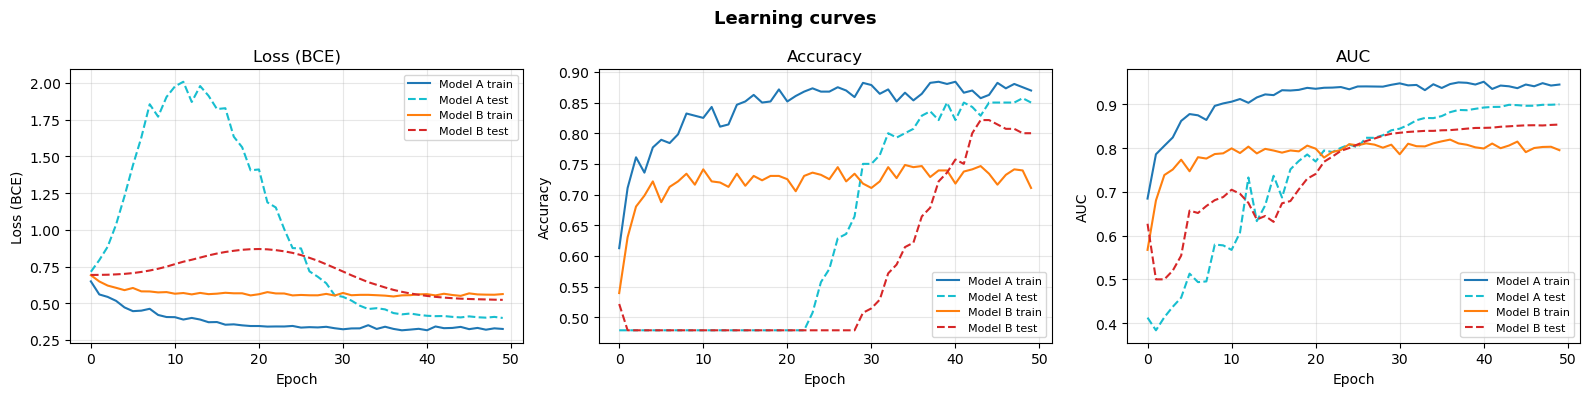

In [6]:
# Function to plot loss, accuracy and AUC curves for train and test
def plot_history(histories, names):
    fig, axes = plt.subplots(1, 3, figsize=(16, 4))
    metrics = [('loss', 'Loss (BCE)'), ('accuracy', 'Accuracy'), ('auc', 'AUC')]
    colors  = [('tab:blue', 'tab:cyan'), ('tab:orange', 'tab:red')]
    for ax, (metric, ylabel) in zip(axes, metrics):
        for hist, name, (c_train, c_test) in zip(histories, names, colors):
            ax.plot(hist.history[metric],          color=c_train, label=f'{name} train')
            ax.plot(hist.history[f'val_{metric}'],    color=c_test,  label=f'{name} test', linestyle='--')
        ax.set_xlabel('Epoch')
        ax.set_ylabel(ylabel)
        ax.set_title(ylabel)
        ax.legend(fontsize=8)
        ax.grid(alpha=0.3)
    plt.suptitle('Learning curves', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig('curvas_aprendizaje.png', dpi=150, bbox_inches='tight')
    plt.show()

plot_history([history_A, history_B], ['Model A', 'Model B'])

## 5. Evaluation on the Test Set

In [7]:
# Evaluate models on the test set and display metrics
loss_A, acc_A, auc_A = model_A.evaluate(test_dataset, verbose=0)
print(f'Model A — Loss: {loss_A:.4f} | Accuracy: {acc_A:.4f} | AUC: {auc_A:.4f}')

loss_B, acc_B, auc_B = model_B.evaluate(test_dataset, verbose=0)
print(f'Model B — Loss: {loss_B:.4f} | Accuracy: {acc_B:.4f} | AUC: {auc_B:.4f}')


Model A — Loss: 0.3999 | Accuracy: 0.8500 | AUC: 0.9000
Model B — Loss: 0.5232 | Accuracy: 0.8000 | AUC: 0.8538


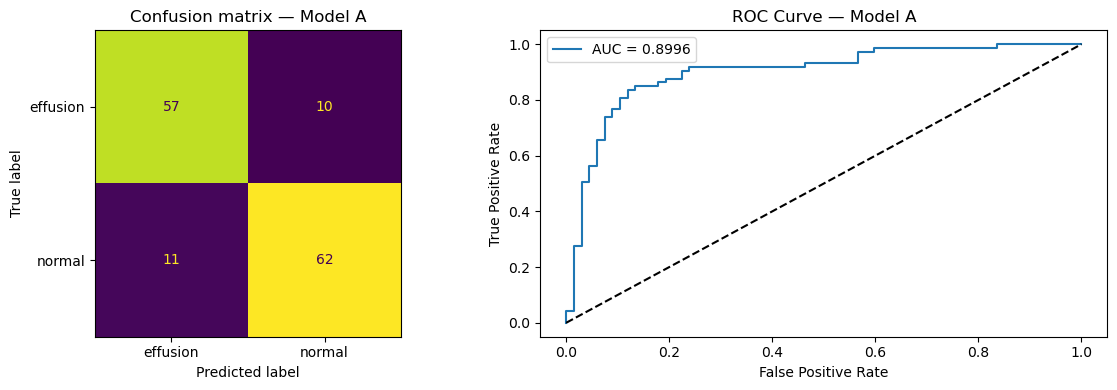

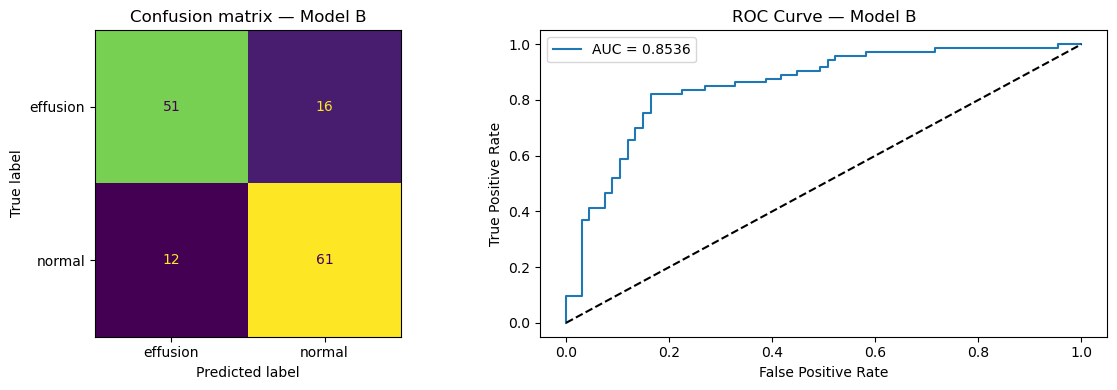

In [8]:
# Function to plot the confusion matrix and ROC curve for Model A and Model B
def plot_results(model, dataset, name, class_names):
    y_true, y_prob = [], []
    for images, labels in dataset:
        probs = model(images, training=False).numpy().ravel()
        y_prob.extend(probs)
        y_true.extend(labels.numpy())

    y_true = np.array(y_true)
    y_prob = np.array(y_prob)
    y_pred = (y_prob >= 0.5).astype(int)

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    cm = confusion_matrix(y_true, y_pred)
    ConfusionMatrixDisplay(cm, display_labels=class_names).plot(ax=axes[0], colorbar=False)
    axes[0].set_title(f'Confusion matrix — {name}')

    fpr, tpr, _ = roc_curve(y_true, y_prob)
    roc_auc = auc(fpr, tpr)
    axes[1].plot(fpr, tpr, label=f'AUC = {roc_auc:.4f}')
    axes[1].plot([0,1], [0,1], 'k--')
    axes[1].set_xlabel('False Positive Rate')
    axes[1].set_ylabel('True Positive Rate')
    axes[1].set_title(f'ROC Curve — {name}')
    axes[1].legend()

    plt.tight_layout()
    plt.savefig(f'resultats_{name}.png', dpi=150, bbox_inches='tight')
    plt.show()

plot_results(model_A, test_dataset, 'Model A', class_names)
plot_results(model_B, test_dataset, 'Model B', class_names)

### Comparative Summary Table

In [9]:
import pandas as pd

# Collect metrics from both models
results = []
for model, name in [(model_A, 'Model A — Lightweight'), (model_B, 'Model B — Deep')]:
    y_true, y_prob = [], []
    for images, labels in test_dataset:
        probs = model(images, training=False).numpy().ravel()
        y_prob.extend(probs)
        y_true.extend(labels.numpy())
    
    y_true = np.array(y_true)
    y_prob = np.array(y_prob)
    y_pred = (y_prob >= 0.5).astype(int)
    
    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    roc_auc = auc(fpr, tpr)
    
    results.append({
        'Model': name,
        'Accuracy': f'{(tp+tn)/(tp+tn+fp+fn):.4f}',
        'AUC': f'{roc_auc:.4f}',
        'Sensitivity': f'{tp/(tp+fn):.4f}',
        'Specificity': f'{tn/(tn+fp):.4f}',
        'Precision': f'{tp/(tp+fp):.4f}',
        'FP': fp,
        'FN': fn
    })

df = pd.DataFrame(results).set_index('Model')
print(df.to_string())

                      Accuracy     AUC Sensitivity Specificity Precision  FP  FN
Model                                                                           
Model A — Lightweight   0.8500  0.8996      0.8493      0.8507    0.8611  10  11
Model B — Deep          0.8000  0.8536      0.8356      0.7612    0.7922  16  12


## 6. Visualisation of Incorrect Predictions

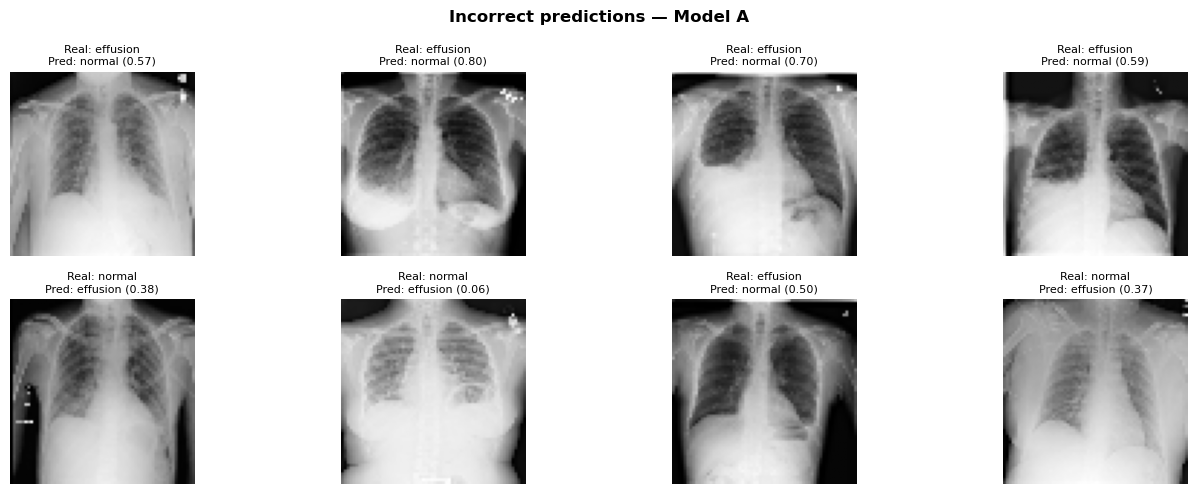

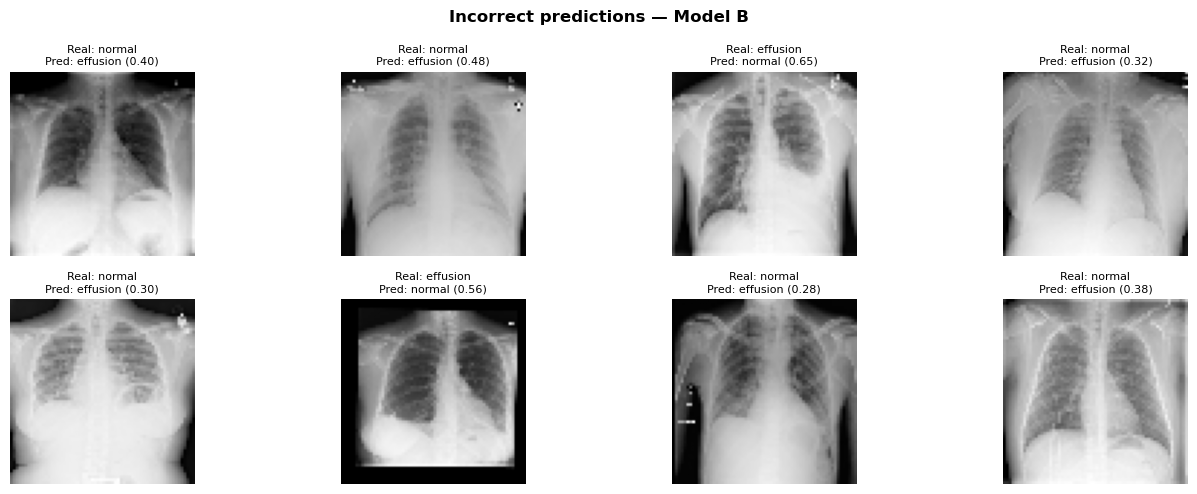

In [10]:
# Function to show images where the model was wrong, with the true class, predicted class and associated probability
def show_errors(model, dataset, name, class_names, n=8):
    y_true, y_prob, images_all = [], [], []
    for images, labels in dataset:
        probs = model(images, training=False).numpy().ravel()
        y_prob.extend(probs)
        y_true.extend(labels.numpy())
        images_all.extend(images.numpy())

    y_true = np.array(y_true)
    y_prob = np.array(y_prob)
    y_pred = (y_prob >= 0.5).astype(int)
    images_all = np.array(images_all)

    errors = np.where(y_pred != y_true.astype(int))[0]
    n = min(n, len(errors))
    if n == 0:
        print('No errors!')
        return

    fig, axes = plt.subplots(2, n//2, figsize=(14, 5))
    axes = axes.ravel()
    for i, idx in enumerate(errors[:n]):
        axes[i].imshow(images_all[idx].squeeze(), cmap='gray')
        true_cls = class_names[int(y_true[idx])]
        pred_cls = class_names[y_pred[idx]]
        prob     = y_prob[idx]
        axes[i].set_title(f'Real: {true_cls}\nPred: {pred_cls} ({prob:.2f})', fontsize=8)
        axes[i].axis('off')

    plt.suptitle(f'Incorrect predictions — {name}', fontweight='bold')
    plt.tight_layout()
    plt.savefig(f'errors_{name[:6]}.png', dpi=150, bbox_inches='tight')
    plt.show()

show_errors(model_A, test_dataset, 'Model A', class_names)
show_errors(model_B, test_dataset, 'Model B', class_names)